In [1]:
import os, sys

# Make sure we're in the project root
os.chdir("/Users/danesh/Documents/GitHub/trueQ")

# Ensure project root is on sys.path
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from config import *
from noise_models import *
from cer import *

In [2]:
noisy_sim = sim_gate_ind[1][0]
noisy_gates = noisy_gates_dict(noisy_sim)

In [3]:
def get_dressed_cycles(circuit: tq.Circuit):

    return [tq.Circuit(circuit[2*k:2*k+2]) for k in range(circuit.n_cycles//2 -1)] + [[circuit[-2]]]

In [4]:
circ = tq.Circuit(3*[{0:Gate.x, 1:Gate.x, 2:Gate.s},{0:Gate.h, (2,1) : Gate.cx}]+[{0:Gate.i, 1:Gate.i, 2:Gate.y}])
circ.measure_all()

Circuit(Cycle((0,): Gate.x, (1,): Gate.x, (2,): Gate.s),Cycle((0,): Gate.h, (2, 1): Gate.cx),Cycle((0,): Gate.x, (1,): Gate.x, (2,): Gate.s),Cycle((0,): Gate.h, (2, 1): Gate.cx),Cycle((0,): Gate.x, (1,): Gate.x, (2,): Gate.s),Cycle((0,): Gate.h, (2, 1): Gate.cx),Cycle((0,): Gate.id, (1,): Gate.id, (2,): Gate.y),Cycle((0,): Meas(), (1,): Meas(), (2,): Meas(), marker=1))

In [5]:
circ.draw()

DisplayWrapper(<svg xmlns="http://w...)

In [6]:
dressed_cycle = get_dressed_cycles(circ)[0]

In [7]:
get_dressed_cycles(circ)

[Circuit(Cycle((0,): Gate.x, (1,): Gate.x, (2,): Gate.s),Cycle((0,): Gate.h, (2, 1): Gate.cx)),
 Circuit(Cycle((0,): Gate.x, (1,): Gate.x, (2,): Gate.s),Cycle((0,): Gate.h, (2, 1): Gate.cx)),
 Circuit(Cycle((0,): Gate.x, (1,): Gate.x, (2,): Gate.s),Cycle((0,): Gate.h, (2, 1): Gate.cx)),
 [Cycle((0,): Gate.id, (1,): Gate.id, (2,): Gate.y)]]

In [8]:
hard_cycle = dressed_cycle[-1]
easy_cycle = dressed_cycle[0]

In [9]:
import numpy as np
from functools import reduce

def tensor_product_list(tensor_list):
    return reduce(np.kron, tensor_list)


In [10]:
lst = []
for qubit, hard_gate in sorted(hard_cycle.gates.items()):
    
    if hard_gate in [Gate.h, Gate.t]:
        easy_gate = easy_cycle.gates[qubit]
        lst.append(effective_dressed_gate(hard_gate, easy_gate, noisy_gates=noisy_gates))
        print(f"Qubit {qubit}: {hard_gate} over {easy_gate}")

    if hard_gate == Gate.cx:
        easy_gate_0 = easy_cycle.gates[(qubit[0],)]
        easy_gate_1 = easy_cycle.gates[(qubit[1],)]
        lst.append(effective_dressed_gate(hard_gate, tq.Gate(np.kron(easy_gate_0.mat, easy_gate_1.mat)), noisy_gates=noisy_gates))
        print(f"Qubits {qubit}: {hard_gate} over ({easy_gate_0}, {easy_gate_1})")

Qubit (0,): Gate.h over Gate.x
Qubits (2, 1): Gate.cx over (Gate.s, Gate.x)


In [11]:
def effective_first_dressed_gate(hard_gate: tq.Gate, easy_gate: tq.Gate, noisy_gates: dict):
    
    lst = []
    if hard_gate == Gate.h:
        for p1 in paulis:
            circ = tq.Circuit([{0:p1@noisy_gates[hard_gate]@noisy_gates[correction_gate(hard_gate,p1)@easy_gate]}])
            lst.append(tqm.Superop.from_unitary(tq.Simulator().operator(circuit=circ).mat()).ptm)    

    
    if hard_gate == Gate.t:
        for p1 in easy_gates:
            circ = tq.Circuit([{0:p1@noisy_gates[hard_gate]@noisy_gates[correction_gate(hard_gate,p1)@easy_gate]}])
            lst.append(tqm.Superop.from_unitary(tq.Simulator().operator(circuit=circ).mat()).ptm)
    
    if hard_gate == Gate.cnot:
        for (p1,p2) in two_q_paulis.keys():
            circ = tq.Circuit([{0:two_q_paulis[(p1,p2)]@noisy_gates[hard_gate]@noisy_gates[correction_gate(hard_gate,two_q_paulis[(p1,p2)])@easy_gate]}])
            lst.append(tqm.Superop.from_unitary(tq.Simulator().operator(circuit=circ).mat()).ptm)
    
    return tqm.Superop.from_ptm(np.mean(lst, axis=0)).ptm

In [12]:
def effective_first_dressed_cycle(dressed_cycle: list, noisy_gates: dict):

    lst = []

    hard_cycle = dressed_cycle[1]
    easy_cycle = dressed_cycle[0]

    for qubit, hard_gate in sorted(hard_cycle.gates.items()):
        
        if hard_gate in [Gate.h, Gate.t]:
            easy_gate = easy_cycle.gates[qubit]
            lst.append(effective_first_dressed_gate(hard_gate, easy_gate, noisy_gates=noisy_gates))

        if hard_gate == Gate.cx:
            easy_gate_0 = easy_cycle.gates[(qubit[0],)]
            easy_gate_1 = easy_cycle.gates[(qubit[1],)]
            lst.append(effective_dressed_gate(hard_gate, tq.Gate(np.kron(easy_gate_0.mat, easy_gate_1.mat)), noisy_gates=noisy_gates))
    
    return tensor_product_list(lst)

In [13]:
def effective_last_dressed_gate(easy_gate: tq.Gate, noisy_gates: dict):
    
    lst = []

    for p1 in paulis:
        circ = tq.Circuit([{0:noisy_gates[easy_gate @ p1]@p1.adj}])
        lst.append(tqm.Superop.from_unitary(tq.Simulator().operator(circuit=circ).mat()).ptm)    
    return tqm.Superop.from_ptm(np.mean(lst, axis=0)).ptm

In [14]:
def effective_last_dressed_cycle(last_dressed_cycle: list, noisy_gates: dict):
    
    lst = []

    easy_cycle = last_dressed_cycle[0]

    for qubit, easy_gate in sorted(easy_cycle.gates.items()):
        
        easy_gate = easy_cycle.gates[qubit]
        lst.append(effective_last_dressed_gate(easy_gate, noisy_gates=noisy_gates))
    
    return tensor_product_list(lst)

In [15]:
def effective_dressed_cycle(dressed_cycle: list, noisy_gates: dict):

    lst = []

    hard_cycle = dressed_cycle[1]
    easy_cycle = dressed_cycle[0]

    for qubit, hard_gate in sorted(hard_cycle.gates.items()):
        
        if hard_gate in [Gate.h, Gate.t]:
            easy_gate = easy_cycle.gates[qubit]
            lst.append(effective_dressed_gate(hard_gate, easy_gate, noisy_gates=noisy_gates))

        if hard_gate == Gate.cx:
            easy_gate_0 = easy_cycle.gates[(qubit[0],)]
            easy_gate_1 = easy_cycle.gates[(qubit[1],)]
            lst.append(effective_dressed_gate(hard_gate, tq.Gate(np.kron(easy_gate_0.mat, easy_gate_1.mat)), noisy_gates=noisy_gates))
    
    return tensor_product_list(lst)

In [16]:
def effective_dressed_cycle_noise(dressed_cycle: list, noisy_gates: dict):

    lst = []

    hard_cycle = dressed_cycle[1]
    easy_cycle = dressed_cycle[0]

    for qubit, hard_gate in sorted(hard_cycle.gates.items()):
        
        if hard_gate in [Gate.h, Gate.t]:
            easy_gate = easy_cycle.gates[qubit]
            lst.append(effective_dressed_gate_noise(hard_gate, easy_gate, noisy_gates=noisy_gates))

        if hard_gate == Gate.cx:
            easy_gate_0 = easy_cycle.gates[(qubit[0],)]
            easy_gate_1 = easy_cycle.gates[(qubit[1],)]
            lst.append(effective_dressed_gate_noise(hard_gate, tq.Gate(np.kron(easy_gate_0.mat, easy_gate_1.mat)), noisy_gates=noisy_gates))
    
    return tensor_product_list(lst)

In [25]:
def effective_circuit(circuit: tq.Circuit, noisy_gates: dict):

    dressed_cycles = get_dressed_cycles(circuit)

    lst = []
    
    lst.append(effective_first_dressed_cycle(dressed_cycles[0], noisy_gates=noisy_gates))

    for drs_cycle in dressed_cycles[1:-1]:
        lst.append(effective_dressed_cycle(drs_cycle, noisy_gates=noisy_gates))

    lst.append(effective_last_dressed_cycle(dressed_cycles[-1], noisy_gates=noisy_gates))

    lst = reversed(lst)
    
    return tqm.Superop.from_ptm(reduce(np.matmul, lst))

In [26]:
def rc_circuit(circuit: tq.Circuit, noisy_sim: tq.Simulator, n_randomizations: int):

    sim = tq.Simulator()

    rc_circs = tq.randomly_compile(circuit, n_compilations=n_randomizations)

    lst = []

    for circ in rc_circs:
        lst.append(tqm.Superop.from_unitary(noisy_sim.operator(circuit=circ).mat()).ptm)

    return tqm.Superop.from_ptm(np.mean(lst, axis=0))

In [27]:
def random_cb_circuit(hard_gate: tq.Gate, easy_gate_set: list, depth: int):

    if hard_gate == Gate.cx:
        lst = []
        for i in range(depth):
            t1 = random.choice(easy_gate_set)
            t2 = random.choice(easy_gate_set)
            cycle = [tq.Cycle({0:t1, 1:t2}), tq.Cycle({(0,1):hard_gate}, marker=1)]
            lst.append(cycle[0])
            lst.append(cycle[1])
        t1 = random.choice(easy_gate_set)
        t2 = random.choice(easy_gate_set)
        final_cycle = tq.Cycle({0:t1, 1:t2})
        lst.append(final_cycle)
        circ = tq.Circuit(lst)
        circ.measure_all()
        return circ
    
    else:
        lst = []
        for i in range(depth):
            t = random.choice(easy_gate_set)
            cycle = [tq.Cycle({0:t}), tq.Cycle({0:hard_gate}, marker=1)]
            lst.append(cycle[0])
            lst.append(cycle[1])
        t = random.choice(easy_gate_set)
        final_cycle = tq.Cycle({0:t})
        lst.append(final_cycle)
        circ = tq.Circuit(lst)
        circ.measure_all()
        return circ



In [28]:
effective_circuit(random_cb_circuit(Gate.t, easy_gates, 20), noisy_gates=noisy_gates)

In [36]:
rc_circuit(random_cb_circuit(Gate.t, easy_gates, 5), noisy_sim=noisy_sim, n_randomizations=500)

In [37]:
def cer_gap(circuit: tq.Circuit, noisy_sim: tq.Simulator):
    eff_circ = effective_circuit(circuit, noisy_gates=noisy_gates_dict(noisy_sim))
    rc_circ = rc_circuit(circuit, noisy_sim=noisy_sim, n_randomizations=500)
    return (rc_circ@eff_circ.adj).fidelity

In [46]:
import csv

def run_cer_gap_sweep(
    depths=(4, 8, 12, 16, 20),
    n_circuits=20,
    noise_model_label="gate_independent",
    csv_path="cer_gap_gate_independent.csv",
):
    fieldnames = ["Gate", "depth", "gap", "noise_model"]
    results = []

    with open(csv_path, mode="w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for depth in depths:
            for i in range(n_circuits):
                circ = random_cb_circuit(Gate.h, paulis, depth)
                gap_val = 1-cer_gap(circ, noisy_sim=sim_gate_ind[1][0])
                row = {
                    "Gate": str(Gate.h),
                    "depth": depth,
                    "gap": float(gap_val),
                    "noise_model": noise_model_label,
                }
                writer.writerow(row)
                f.flush()  # ensure it’s written to disk incrementally

                print(
                    f"Finished: Gate={Gate.h}, depth={depth}, "
                    f"circuit {i+1}/{n_circuits}, gap={gap_val}"
                )

                results.append(row)

    return results

results = run_cer_gap_sweep(
    depths=(4, 8, 12, 16, 20),
    n_circuits=20,
    noise_model_label="gate_independent",
    csv_path="cer_gap_gate_independent.csv",
)

Finished: Gate=Gate.h, depth=4, circuit 1/20, gap=0.011229588852898709
Finished: Gate=Gate.h, depth=4, circuit 2/20, gap=0.011188128289616905
Finished: Gate=Gate.h, depth=4, circuit 3/20, gap=0.010986330572552605
Finished: Gate=Gate.h, depth=4, circuit 4/20, gap=0.011399883903464136
Finished: Gate=Gate.h, depth=4, circuit 5/20, gap=0.011193471351038431
Finished: Gate=Gate.h, depth=4, circuit 6/20, gap=0.011239485280986283
Finished: Gate=Gate.h, depth=4, circuit 7/20, gap=0.011672146637668912
Finished: Gate=Gate.h, depth=4, circuit 8/20, gap=0.011623180456546534
Finished: Gate=Gate.h, depth=4, circuit 9/20, gap=0.011134077391927955
Finished: Gate=Gate.h, depth=4, circuit 10/20, gap=0.010892211666580498
Finished: Gate=Gate.h, depth=4, circuit 11/20, gap=0.011389355463686357
Finished: Gate=Gate.h, depth=4, circuit 12/20, gap=0.011082305171848272
Finished: Gate=Gate.h, depth=4, circuit 13/20, gap=0.010962254351848721
Finished: Gate=Gate.h, depth=4, circuit 14/20, gap=0.011428661350820102
F

In [49]:
import csv

def run_cer_gap_sweep(
    depths=(4, 8, 12, 16, 20),
    n_circuits=20,
    noise_model_label="over_rotation",
    csv_path="cer_gap_over_rotation.csv",
):
    fieldnames = ["Gate", "depth", "gap", "noise_model"]
    results = []

    with open(csv_path, mode="w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for depth in depths:
            for i in range(n_circuits):
                circ = random_cb_circuit(Gate.h, paulis, depth)
                gap_val = 1- cer_gap(circ, noisy_sim=sim_gate_dep[1][0])

                row = {
                    "Gate": str(Gate.h),
                    "depth": depth,
                    "gap": float(gap_val),
                    "noise_model": noise_model_label,
                }
                writer.writerow(row)
                f.flush()  # ensure it’s written to disk incrementally

                print(
                    f"Finished: Gate={Gate.h}, depth={depth}, "
                    f"circuit {i+1}/{n_circuits}, gap={gap_val}"
                )

                results.append(row)

    return results

results = run_cer_gap_sweep(
    depths=(4, 8, 12, 16, 20),
    n_circuits=20,
    noise_model_label="over_rotation",
    csv_path="cer_gap_over_rotation.csv",
)

Finished: Gate=Gate.h, depth=4, circuit 1/20, gap=0.011434917688670554
Finished: Gate=Gate.h, depth=4, circuit 2/20, gap=0.011150337113263076
Finished: Gate=Gate.h, depth=4, circuit 3/20, gap=0.01131355700644554
Finished: Gate=Gate.h, depth=4, circuit 4/20, gap=0.011352029024837229
Finished: Gate=Gate.h, depth=4, circuit 5/20, gap=0.011259251021712657
Finished: Gate=Gate.h, depth=4, circuit 6/20, gap=0.011251677411856509
Finished: Gate=Gate.h, depth=4, circuit 7/20, gap=0.010867023599777426
Finished: Gate=Gate.h, depth=4, circuit 8/20, gap=0.01171388646377225
Finished: Gate=Gate.h, depth=4, circuit 9/20, gap=0.011026437372958497
Finished: Gate=Gate.h, depth=4, circuit 10/20, gap=0.01102880899799863
Finished: Gate=Gate.h, depth=4, circuit 11/20, gap=0.01154550813863997
Finished: Gate=Gate.h, depth=4, circuit 12/20, gap=0.011468264153296603
Finished: Gate=Gate.h, depth=4, circuit 13/20, gap=0.011387116679314246
Finished: Gate=Gate.h, depth=4, circuit 14/20, gap=0.010928488588163532
Finis

In [50]:
import csv

def run_cer_gap_sweep(
    depths=(4, 8, 12, 16, 20),
    n_circuits=20,
    noise_model_label="ZX_decomposition",
    csv_path="cer_gap_ZX_decomposition.csv",
):
    fieldnames = ["Gate", "depth", "gap", "noise_model"]
    results = []

    with open(csv_path, mode="w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for depth in depths:
            for i in range(n_circuits):
                circ = random_cb_circuit(Gate.h, paulis, depth)
                gap_val = 1- cer_gap(circ, noisy_sim=sim_gate_dep[1][0])

                row = {
                    "Gate": str(Gate.h),
                    "depth": depth,
                    "gap": float(gap_val),
                    "noise_model": noise_model_label,
                }
                writer.writerow(row)
                f.flush()  # ensure it’s written to disk incrementally

                print(
                    f"Finished: Gate={Gate.h}, depth={depth}, "
                    f"circuit {i+1}/{n_circuits}, gap={gap_val}"
                )

                results.append(row)

    return results

results = run_cer_gap_sweep(
    depths=(4, 8, 12, 16, 20),
    n_circuits=20,
    noise_model_label="ZX_decomposition",
    csv_path="cer_gap_ZX_decomposition.csv",
)

Finished: Gate=Gate.h, depth=4, circuit 1/20, gap=0.011219813722077365
Finished: Gate=Gate.h, depth=4, circuit 2/20, gap=0.011170121863956606
Finished: Gate=Gate.h, depth=4, circuit 3/20, gap=0.01127973450459141
Finished: Gate=Gate.h, depth=4, circuit 4/20, gap=0.010753344629444772
Finished: Gate=Gate.h, depth=4, circuit 5/20, gap=0.01142436233035049
Finished: Gate=Gate.h, depth=4, circuit 6/20, gap=0.011167405385332119
Finished: Gate=Gate.h, depth=4, circuit 7/20, gap=0.011454155533997534
Finished: Gate=Gate.h, depth=4, circuit 8/20, gap=0.011136212522431688
Finished: Gate=Gate.h, depth=4, circuit 9/20, gap=0.011210190561984579
Finished: Gate=Gate.h, depth=4, circuit 10/20, gap=0.01114290490052261
Finished: Gate=Gate.h, depth=4, circuit 11/20, gap=0.011355394139509256
Finished: Gate=Gate.h, depth=4, circuit 12/20, gap=0.01100574868165416
Finished: Gate=Gate.h, depth=4, circuit 13/20, gap=0.011299817327149686
Finished: Gate=Gate.h, depth=4, circuit 14/20, gap=0.01138686890504581
Finish

In [51]:
import pandas as pd

# Load individual result files
df_gate_ind = pd.read_csv("cer_gap_gate_independent.csv")
df_over_rot = pd.read_csv("cer_gap_over_rotation.csv")
df_zx_dec = pd.read_csv("cer_gap_ZX_decomposition.csv")

# Concatenate into a single DataFrame
df_all = pd.concat([df_gate_ind, df_over_rot, df_zx_dec], ignore_index=True)

# Ensure proper types
df_all["depth"] = df_all["depth"].astype(int)
df_all["gap"] = df_all["gap"].astype(float)

df_all.head()

,Gate,depth,gap,noise_model
0,Gate.h,4,0.011230,gate_independent
1,Gate.h,4,0.011188,gate_independent
2,Gate.h,4,0.010986,gate_independent
3,Gate.h,4,0.011400,gate_independent
4,Gate.h,4,0.011193,gate_independent


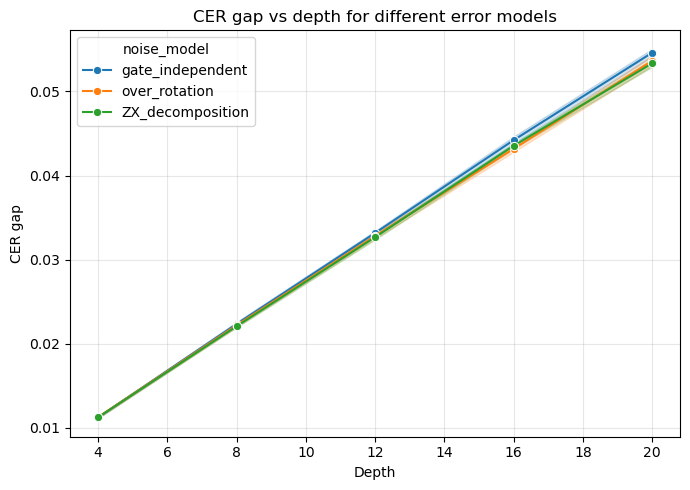

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.lineplot(
    data=df_all,
    x="depth",
    y="gap",
    hue="noise_model",
    marker="o",
)
plt.xlabel("Depth")
plt.ylabel("CER gap")
plt.title("CER gap vs depth for different error models")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()